<a href="https://colab.research.google.com/github/DilshanBotheju/CSACP_Project/blob/main/HomicidePatternRecognizerClusteringModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [35]:
#Load relevant datasets
homicide_data_path = "/content/drive/MyDrive/DSGP/datasets/preprocessed_dataset.csv"
homicide_data = pd.read_csv(homicide_data_path, encoding = "latin-1")
homicide_data.head(10)

,City,State,Year,Month,Incident,Crime Type,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,1,Murder or Manslaughter,Male,18,White,Male,0.0,White,Acquaintance,Handgun,1,0,Teen (13-19),NaN
1,Harris,Texas,2013,5,3,Murder or Manslaughter,Male,27,White,Male,0.0,White,Acquaintance,Firearm,0,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,1,Murder or Manslaughter,Male,42,Black,Male,18.0,Black,Acquaintance,Handgun,0,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,6,Murder or Manslaughter,Male,44,White,Male,0.0,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,1,Murder or Manslaughter,Female,15,White,Male,20.0,White,Girlfriend,Rifle,0,0,Teen (13-19),Young Adult (20-29)
5,Kalkaska,Michigan,2008,8,1,Murder or Manslaughter,Male,3,White,Male,25.0,White,Acquaintance,Blunt Object,0,2,Child (0-12),Young Adult (20-29)
6,Spokane,Washington,2001,3,1,Murder or Manslaughter,Male,37,White,Male,0.0,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
7,Baltimore city,Maryland,2005,1,13,Murder or Manslaughter,Male,22,Black,Male,0.0,White,Acquaintance,Handgun,0,0,Young Adult (20-29),NaN
8,Lafayette,Louisiana,2014,2,1,Murder or Manslaughter,Male,49,White,Male,15.0,Black,Husband,Firearm,0,0,Adult (30-49),Teen (13-19)
9,Gaston,North Carolina,2009,4,1,Murder or Manslaughter,Female,17,Black,Male,21.0,Black,Stranger,Handgun,0,1,Teen (13-19),Young Adult (20-29)


EDA (Exploratory Data Analysis)

<ipython-input-36-372c2f28047c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")


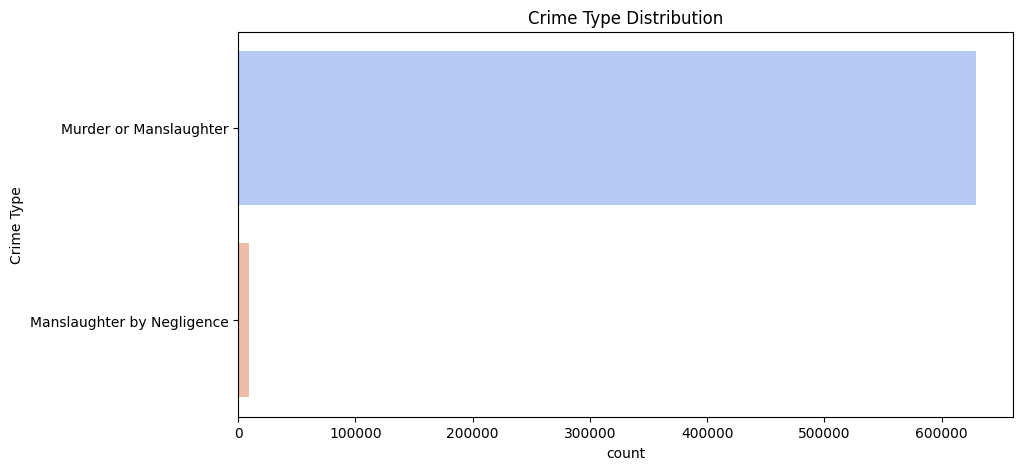

In [36]:
# Distribution of homicide crime types
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")
plt.title("Crime Type Distribution")
plt.show()

<ipython-input-37-b69b9ed5197d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")


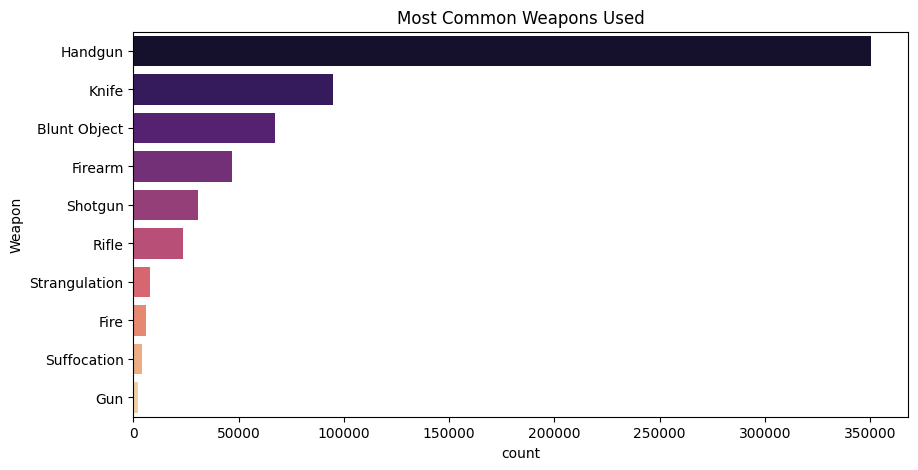

In [37]:
# Plotting most common weapons used
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")
plt.title("Most Common Weapons Used")
plt.show()

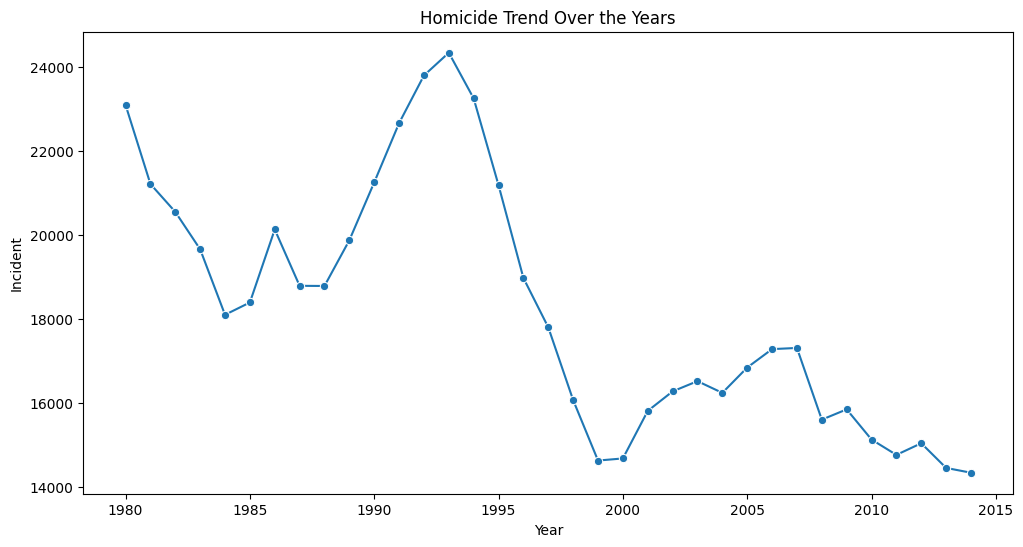

In [38]:
# Identify homicide trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(x="Year", y="Incident", data=homicide_data.groupby("Year")["Incident"].count().reset_index(), marker="o")
plt.title("Homicide Trend Over the Years")
plt.show()

In [39]:
# Drop unnecessary columns
homicide_data = homicide_data.drop(columns=["Perpetrator Age","Victim Age","Incident","Crime Type","Victim Race","Perpetrator Race"])

In [40]:
# View data
homicide_data.head()

,City,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,Male,Male,Acquaintance,Handgun,1,0,Teen (13-19),NaN
1,Harris,Texas,2013,5,Male,Male,Acquaintance,Firearm,0,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,Male,Male,Acquaintance,Handgun,0,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,Male,Male,Acquaintance,Handgun,0,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,Female,Male,Girlfriend,Rifle,0,0,Teen (13-19),Young Adult (20-29)


In [41]:
# Check null values
homicide_data.isnull().sum()

,0
City,0
State,0
Year,0
Month,0
Victim Sex,0
Perpetrator Sex,0
Relationship,0
Weapon,0
Victim Count,0
Perpetrator Count,0


In [42]:
# Drop unnecessary columns
homicide_data = homicide_data.drop(columns=["Perpetrator Age Group"])

In [43]:
# Getting a sample percentage of data to preprocess
data_percentage = 0.5
homicide_data = homicide_data.sample(frac=data_percentage, random_state=42)

In [44]:
# Replacing NA with Unknown to identify null columns
homicide_data.replace( np.nan,"Unknown", inplace=True)

In [45]:
# View data
homicide_data.head()

,City,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group
484984,Baltimore city,Maryland,1996,8,Male,Male,Acquaintance,Handgun,0,0,Senior (50+)
608445,Essex,New Jersey,2013,9,Male,Male,Stranger,Handgun,0,0,Young Adult (20-29)
417612,Wayne,Michigan,1997,11,Male,Male,Acquaintance,Firearm,0,0,Young Adult (20-29)
372692,Dade,Florida,1995,12,Male,Male,Son,Blunt Object,0,0,Child (0-12)
402028,Los Angeles,California,2002,11,Male,Male,Stranger,Handgun,0,0,Teen (13-19)


In [46]:
# View dataset info
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 319227 entries, 484984 to 190407
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   City               319227 non-null  object
 1   State              319227 non-null  object
 2   Year               319227 non-null  int64 
 3   Month              319227 non-null  int64 
 4   Victim Sex         319227 non-null  object
 5   Perpetrator Sex    319227 non-null  object
 6   Relationship       319227 non-null  object
 7   Weapon             319227 non-null  object
 8   Victim Count       319227 non-null  int64 
 9   Perpetrator Count  319227 non-null  int64 
 10  Victim Age Group   319227 non-null  object
dtypes: int64(4), object(7)
memory usage: 29.2+ MB


In [47]:
# Get value count for city
homicide_data["City"].value_counts()

,count
City,
Los Angeles,22137
New York,19174
Cook,11086
Wayne,9902
Harris,8179
...,...
Mahaska,1
Ellsworth,1
Concho,1


In [48]:
# Get value count for state
homicide_data["State"].value_counts()

,count
State,
California,49939
Texas,31010
New York,24526
Florida,18463
Michigan,14178
Illinois,12818
Pennsylvania,12285
Georgia,10642
North Carolina,10240


In [49]:
# Drop state and city due to high categorical count
homicide_data = homicide_data.drop(columns=["City","State"])

In [50]:
# Viewing the data
homicide_data.head()

,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group
484984,1996,8,Male,Male,Acquaintance,Handgun,0,0,Senior (50+)
608445,2013,9,Male,Male,Stranger,Handgun,0,0,Young Adult (20-29)
417612,1997,11,Male,Male,Acquaintance,Firearm,0,0,Young Adult (20-29)
372692,1995,12,Male,Male,Son,Blunt Object,0,0,Child (0-12)
402028,2002,11,Male,Male,Stranger,Handgun,0,0,Teen (13-19)


In [51]:
# Get weapon value count
homicide_data["Weapon"].value_counts()

,count
Weapon,
Handgun,175252
Knife,47515
Blunt Object,33759
Firearm,23587
Shotgun,15290
Rifle,11676
Strangulation,4004
Fire,3096
Suffocation,1981


Feature Engineering

In [67]:
# Time Series Analysis
homicide_data["Date"] = pd.to_datetime(homicide_data[['Year', 'Month']].assign(DAY=1))

# Set Date as the index
homicide_data.set_index('Date', inplace=True)

# Ensure the data is sorted
homicide_data = homicide_data.sort_index()

# Count crimes per month
crime_trends = homicide_data.resample('M').size()

# Display the first few rows
print(crime_trends.head())

Date
1980-01-31    923
1980-02-29    816
1980-03-31    832
1980-04-30    926
1980-05-31    921
Freq: ME, dtype: int64


<ipython-input-67-1b92421a5cef>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  crime_trends = homicide_data.resample('M').size()


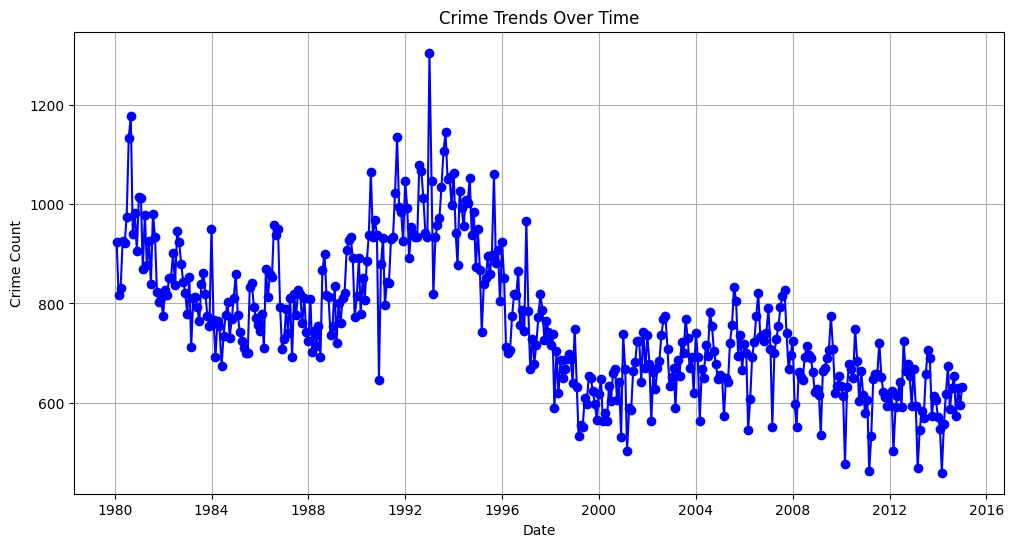

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(crime_trends, marker='o', linestyle='-', color='b')
plt.xlabel("Date")
plt.ylabel("Crime Count")
plt.title("Crime Trends Over Time")
plt.grid()
plt.show()


In [52]:
# One hot encoding categorical features
homicide_data = pd.get_dummies(homicide_data, columns=["Victim Sex", "Perpetrator Sex", "Relationship", "Weapon", "Victim Age Group"], drop_first=False)

In [53]:
homicide_data.head()

,Year,Month,Victim Count,Perpetrator Count,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,Relationship_Acquaintance,Relationship_Boyfriend,...,Weapon_Rifle,Weapon_Shotgun,Weapon_Strangulation,Weapon_Suffocation,Victim Age Group_Adult (30-49),Victim Age Group_Child (0-12),Victim Age Group_Senior (50+),Victim Age Group_Teen (13-19),Victim Age Group_Unknown,Victim Age Group_Young Adult (20-29)
484984,1996,8,0,0,False,True,False,True,True,False,...,False,False,False,False,False,False,True,False,False,False
608445,2013,9,0,0,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
417612,1997,11,0,0,False,True,False,True,True,False,...,False,False,False,False,False,False,False,False,False,True
372692,1995,12,0,0,False,True,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
402028,2002,11,0,0,False,True,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [54]:
# Analyze new columns
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 319227 entries, 484984 to 190407
Data columns (total 56 columns):
 #   Column                                Non-Null Count   Dtype
---  ------                                --------------   -----
 0   Year                                  319227 non-null  int64
 1   Month                                 319227 non-null  int64
 2   Victim Count                          319227 non-null  int64
 3   Perpetrator Count                     319227 non-null  int64
 4   Victim Sex_Female                     319227 non-null  bool 
 5   Victim Sex_Male                       319227 non-null  bool 
 6   Perpetrator Sex_Female                319227 non-null  bool 
 7   Perpetrator Sex_Male                  319227 non-null  bool 
 8   Relationship_Acquaintance             319227 non-null  bool 
 9   Relationship_Boyfriend                319227 non-null  bool 
 10  Relationship_Boyfriend/Girlfriend     319227 non-null  bool 
 11  Relationship_Brother      

In [55]:
# Select features after one-hot encoding
features = [
    "Month", "Victim Count", "Perpetrator Count",
    "Victim Sex_Female", "Victim Sex_Male",
    "Perpetrator Sex_Female", "Perpetrator Sex_Male",
    "Relationship_Acquaintance", "Relationship_Boyfriend",
    "Relationship_Boyfriend/Girlfriend", "Relationship_Brother",
    "Relationship_Common-Law Husband", "Relationship_Common-Law Wife",
    "Relationship_Daughter", "Relationship_Employee", "Relationship_Employer",
    "Relationship_Ex-Husband", "Relationship_Ex-Wife", "Relationship_Family",
    "Relationship_Father", "Relationship_Friend", "Relationship_Girlfriend",
    "Relationship_Husband", "Relationship_In-Law", "Relationship_Mother",
    "Relationship_Neighbor", "Relationship_Sister", "Relationship_Son",
    "Relationship_Stepdaughter", "Relationship_Stepfather", "Relationship_Stepmother",
    "Relationship_Stepson", "Relationship_Stranger", "Relationship_Wife",
    "Weapon_Blunt Object", "Weapon_Drowning", "Weapon_Drugs",
    "Weapon_Explosives", "Weapon_Fall", "Weapon_Fire", "Weapon_Firearm",
    "Weapon_Gun", "Weapon_Handgun", "Weapon_Knife", "Weapon_Poison",
    "Weapon_Rifle", "Weapon_Shotgun", "Weapon_Strangulation", "Weapon_Suffocation",
    "Victim Age Group_Adult (30-49)", "Victim Age Group_Child (0-12)",
    "Victim Age Group_Senior (50+)", "Victim Age Group_Teen (13-19)",
    "Victim Age Group_Unknown", "Victim Age Group_Young Adult (20-29)"
]

# Assign the feature matrix
X = homicide_data[features]


In [56]:
homicide_data.head()

,Year,Month,Victim Count,Perpetrator Count,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,Relationship_Acquaintance,Relationship_Boyfriend,...,Weapon_Rifle,Weapon_Shotgun,Weapon_Strangulation,Weapon_Suffocation,Victim Age Group_Adult (30-49),Victim Age Group_Child (0-12),Victim Age Group_Senior (50+),Victim Age Group_Teen (13-19),Victim Age Group_Unknown,Victim Age Group_Young Adult (20-29)
484984,1996,8,0,0,False,True,False,True,True,False,...,False,False,False,False,False,False,True,False,False,False
608445,2013,9,0,0,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
417612,1997,11,0,0,False,True,False,True,True,False,...,False,False,False,False,False,False,False,False,False,True
372692,1995,12,0,0,False,True,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
402028,2002,11,0,0,False,True,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


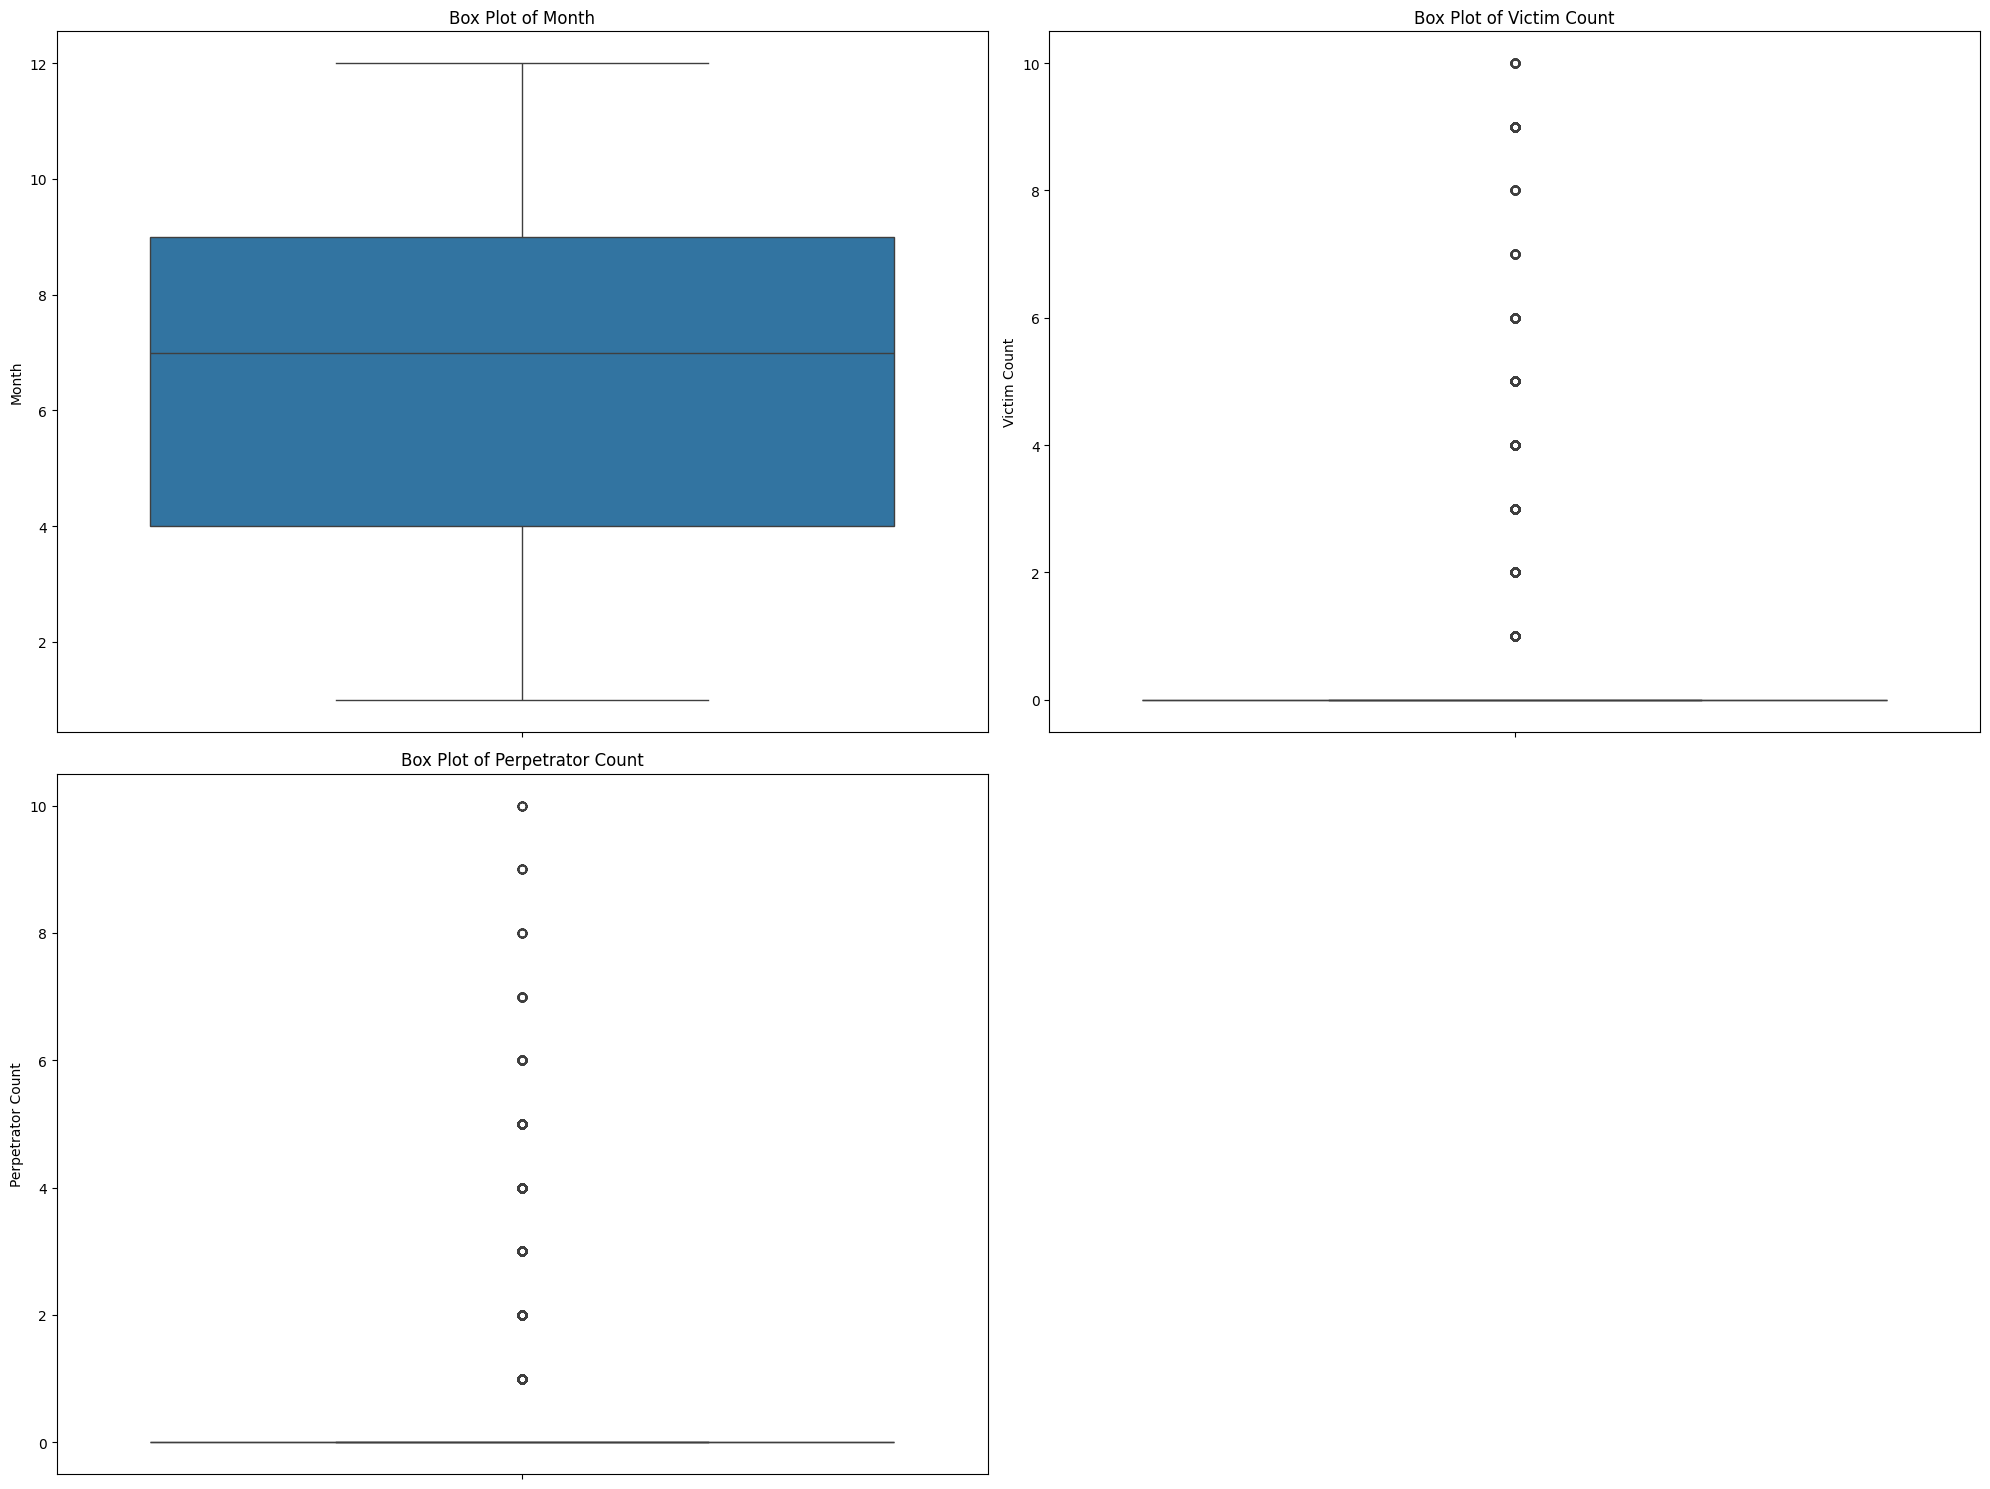

In [57]:
# Figure size
plt.figure(figsize=(20, 15))

# Define numerical and categorical features separately
numerical_features = ["Month", "Victim Count", "Perpetrator Count"]
categorical_features = [feature for feature in features if feature not in numerical_features]

# Number of numerical features
num_numerical = len(numerical_features)

# Plot box plots for numerical features
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=homicide_data[feature])
    plt.title(f"Box Plot of {feature}")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()


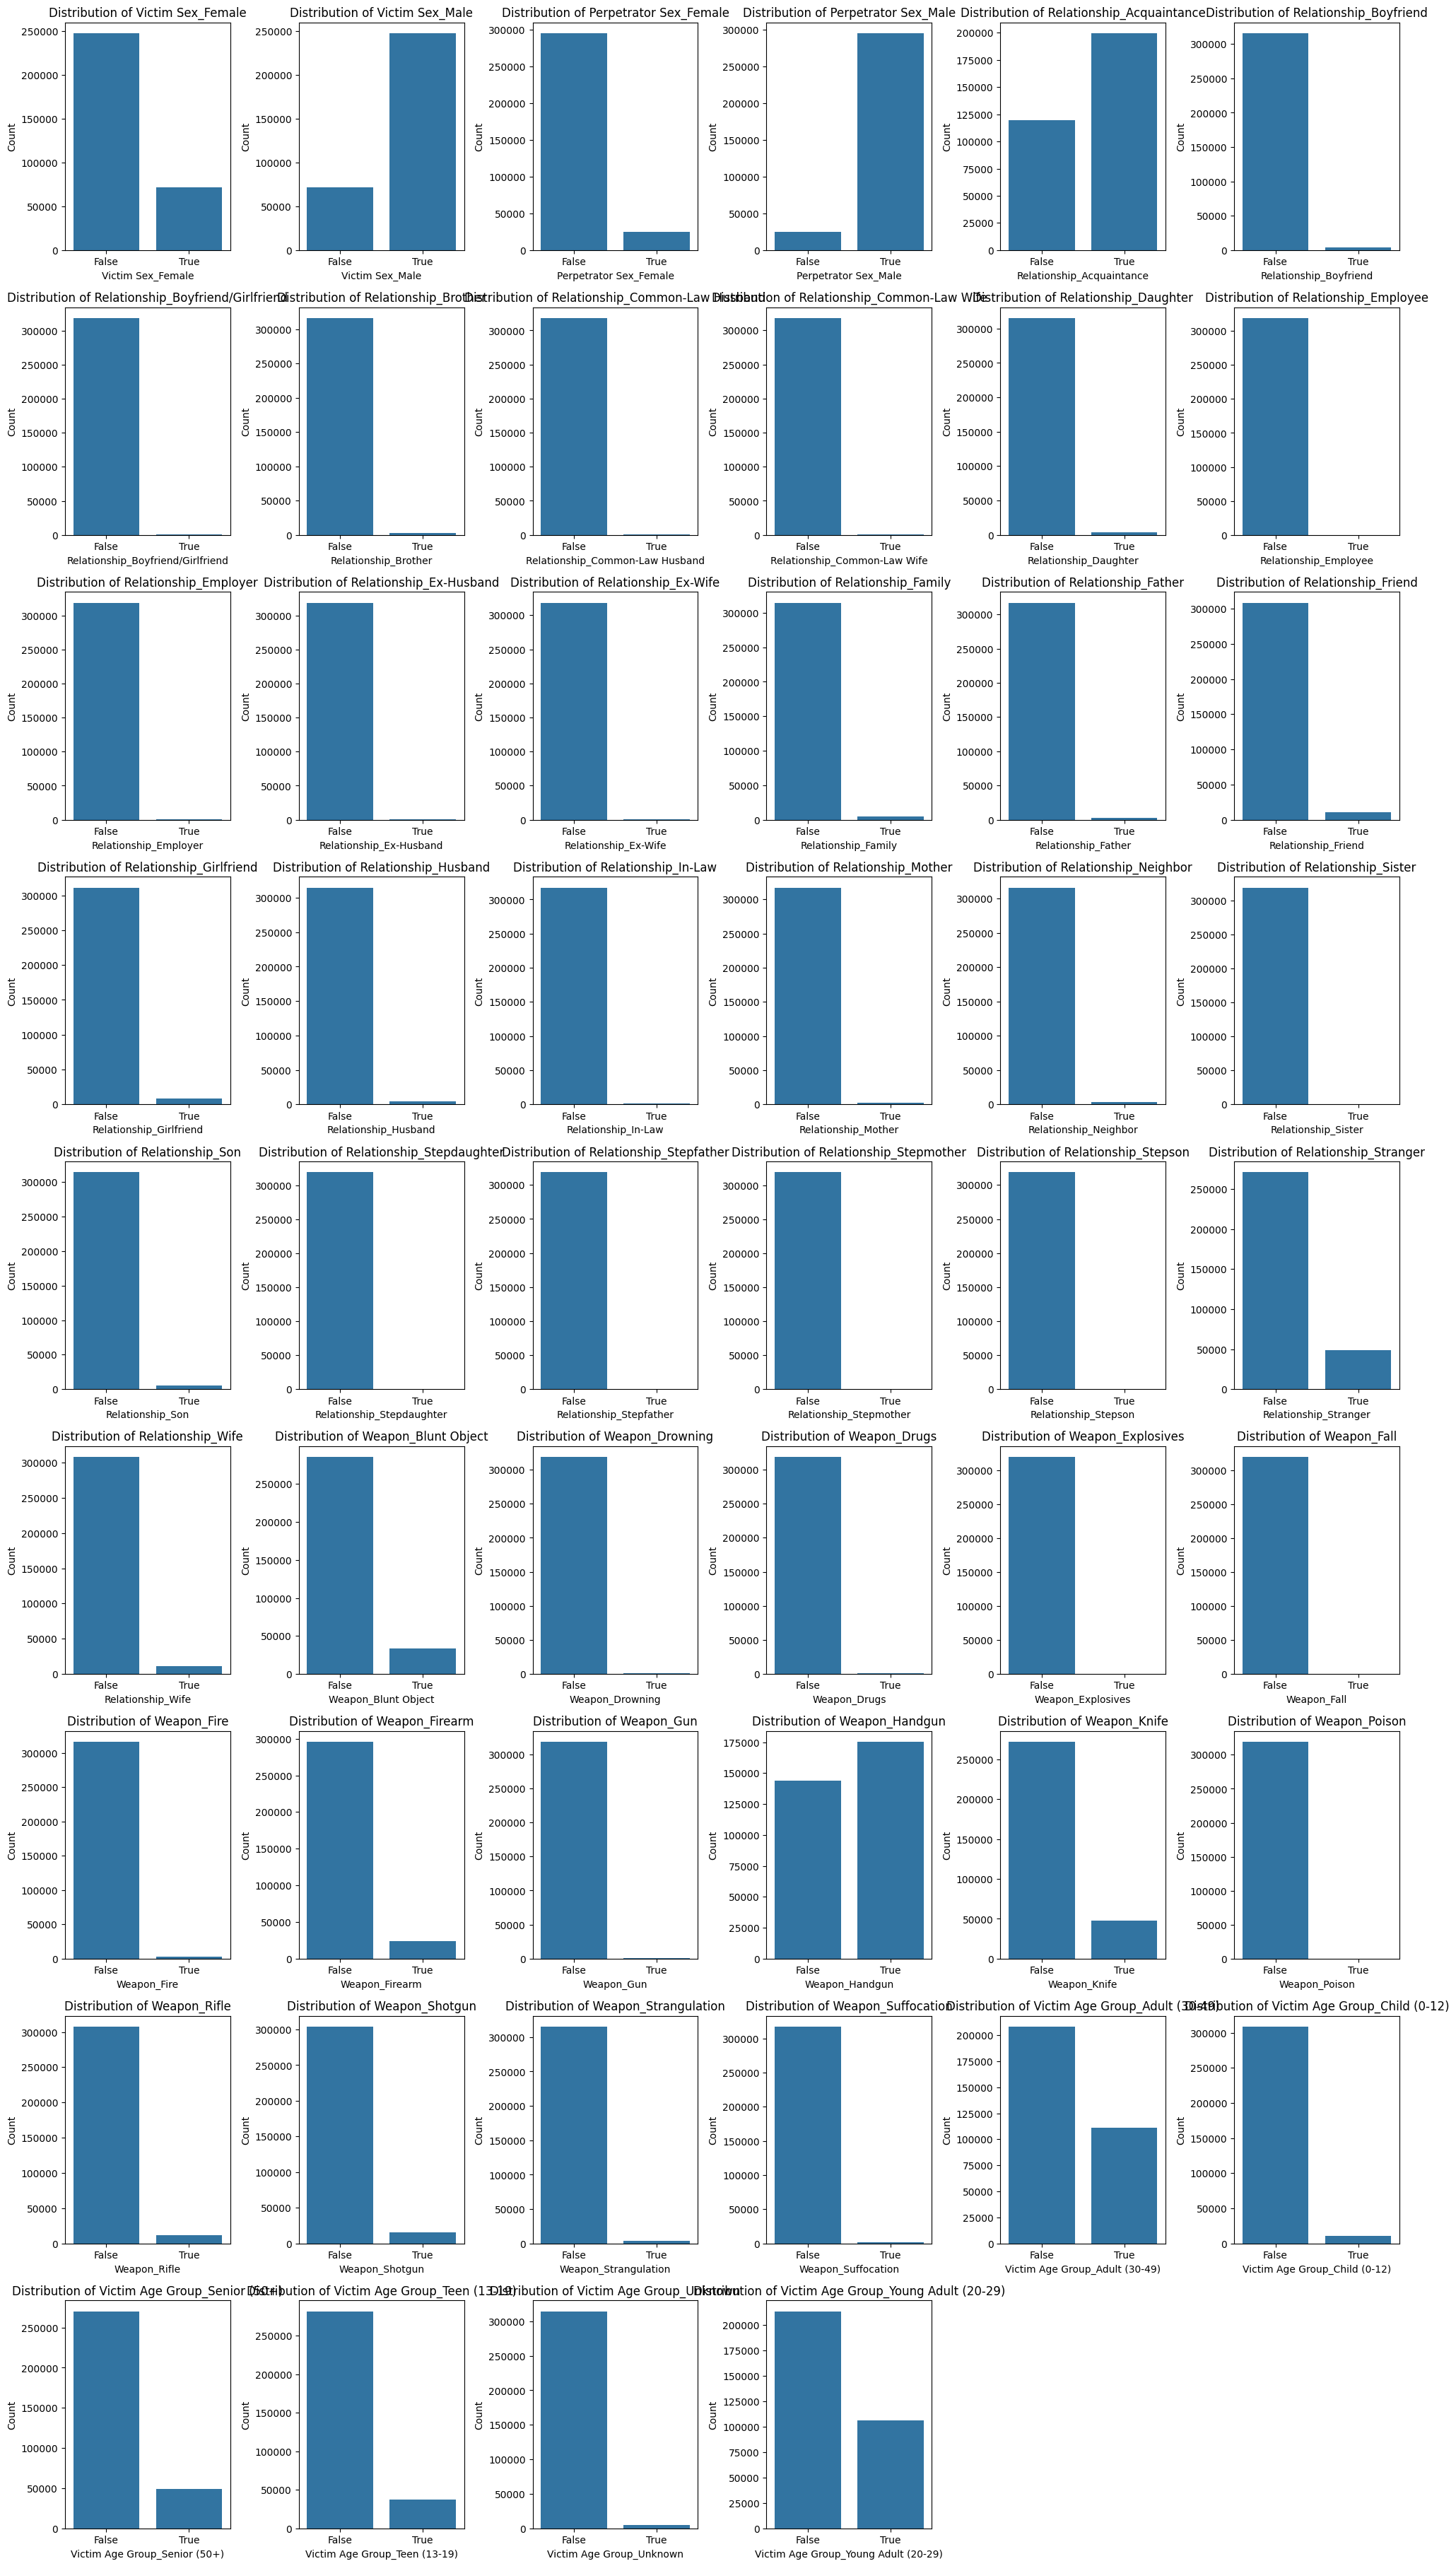

In [58]:
# Plot bar plots for categorical features
plt.figure(figsize=(20, 40))

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(10, 6, i)
    sns.barplot(x=homicide_data[feature].value_counts().index, y=homicide_data[feature].value_counts().values)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [59]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
homicide_data["Month"].value_counts()

KMeans Clustering

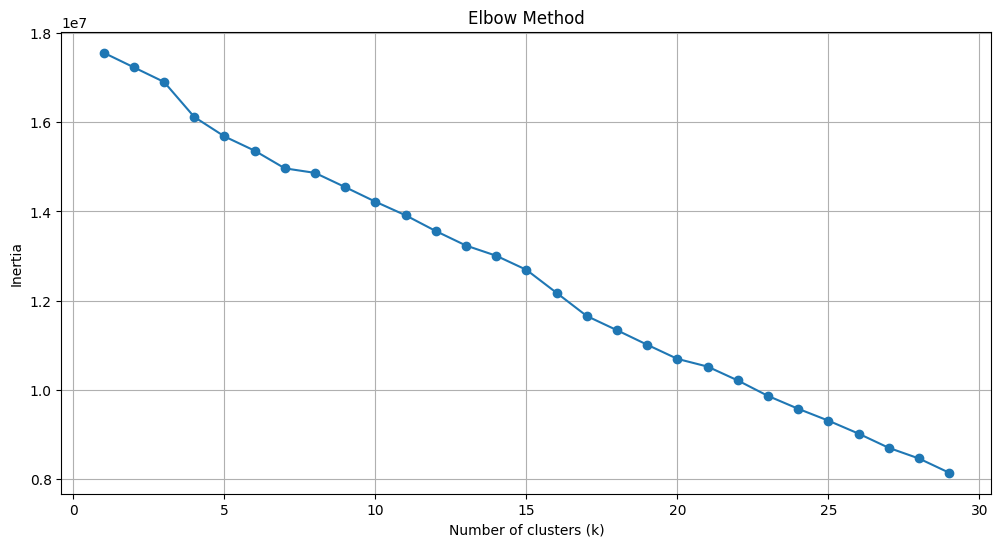

In [64]:
# Using elbow method to identify clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 30):
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(range(1, 30), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

In [121]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42,max_iter=1000)
kmeans.fit(X_scaled)

# Assign clusters to your data
homicide_data["Cluster"] = kmeans.labels_

In [122]:
homicide_data.head()

,City,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Cluster
484984,87,20,1996,8,1,1,0,8,0,0,2,8
608445,539,30,2013,9,1,1,25,8,0,0,5,10
417612,1695,22,1997,11,1,1,0,6,0,0,5,4
372692,425,9,1995,12,1,1,20,0,0,0,1,9
402028,946,4,2002,11,1,1,25,8,0,0,3,10


In [123]:
print(homicide_data["Cluster"].value_counts())

Cluster
2     100532
10     77618
6      70796
1      66343
7      61270
9      60495
4      59969
8      58079
0      47610
3      23156
5      12586
Name: count, dtype: int64


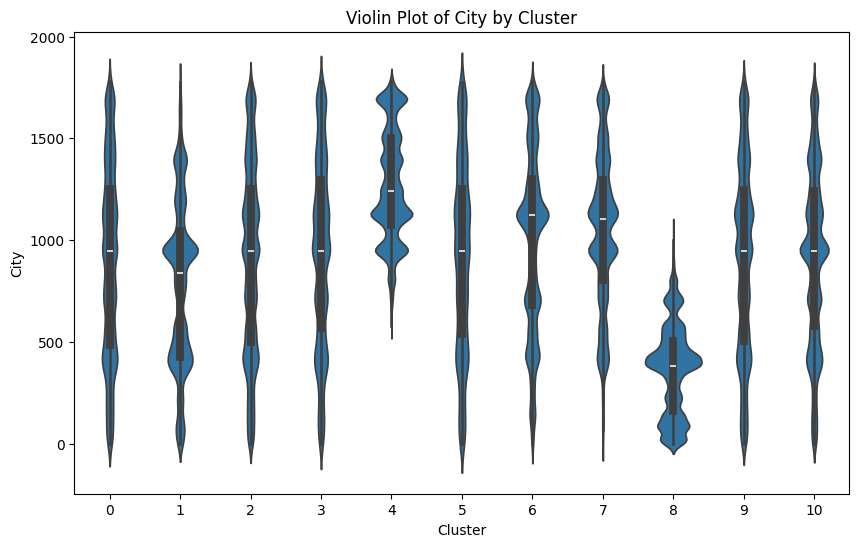

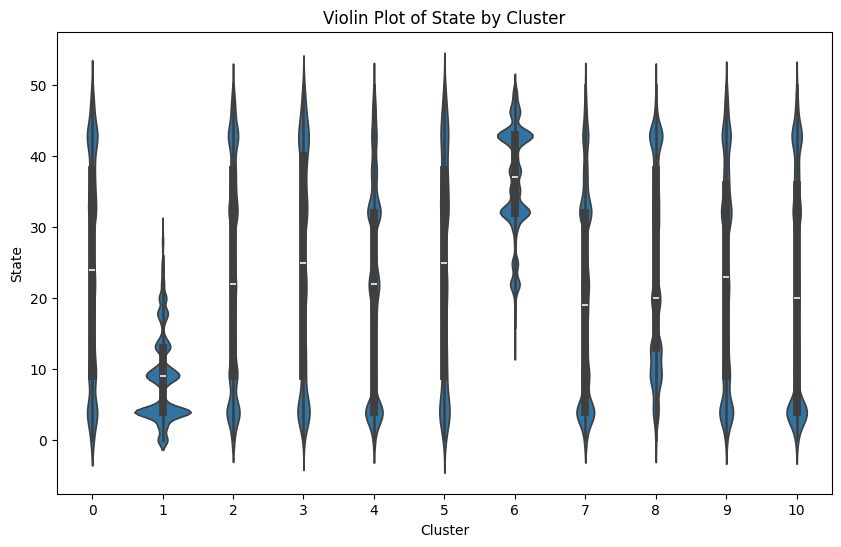

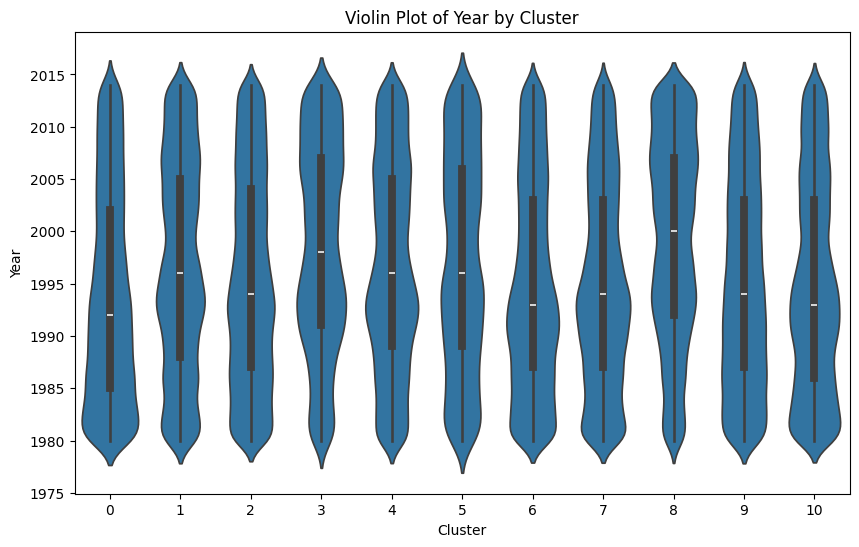

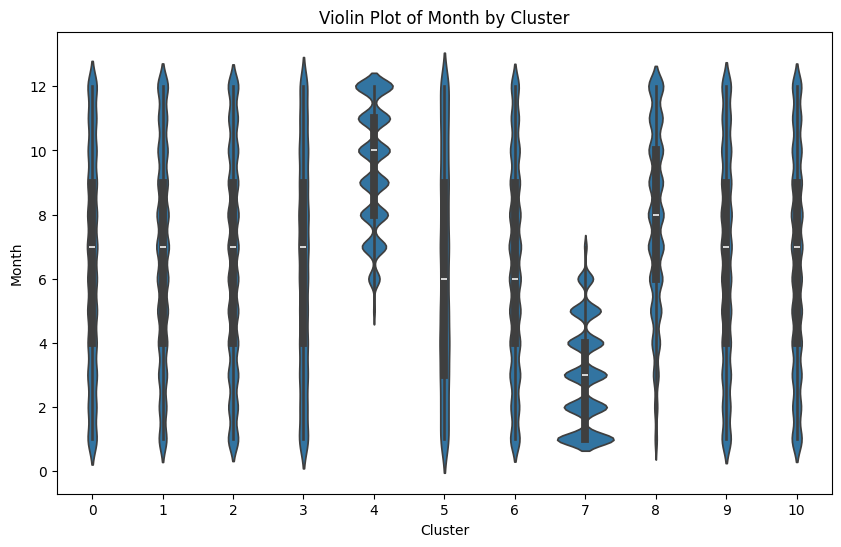

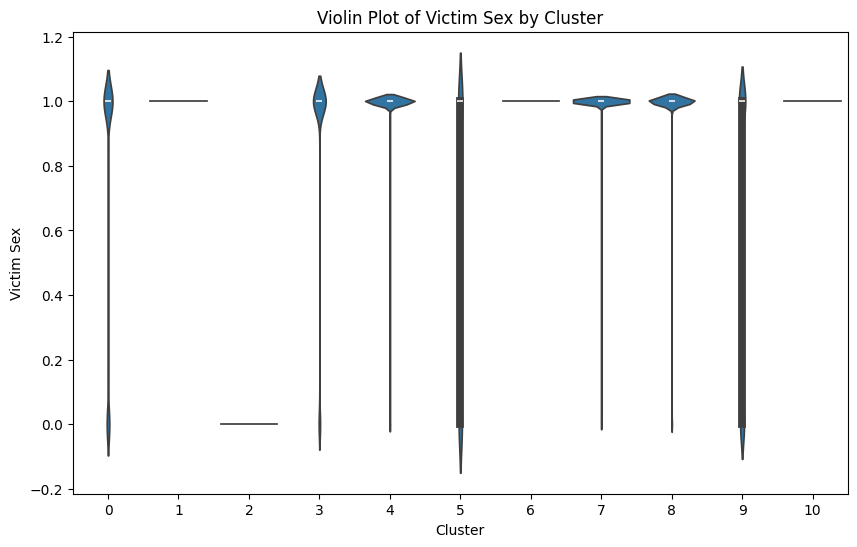

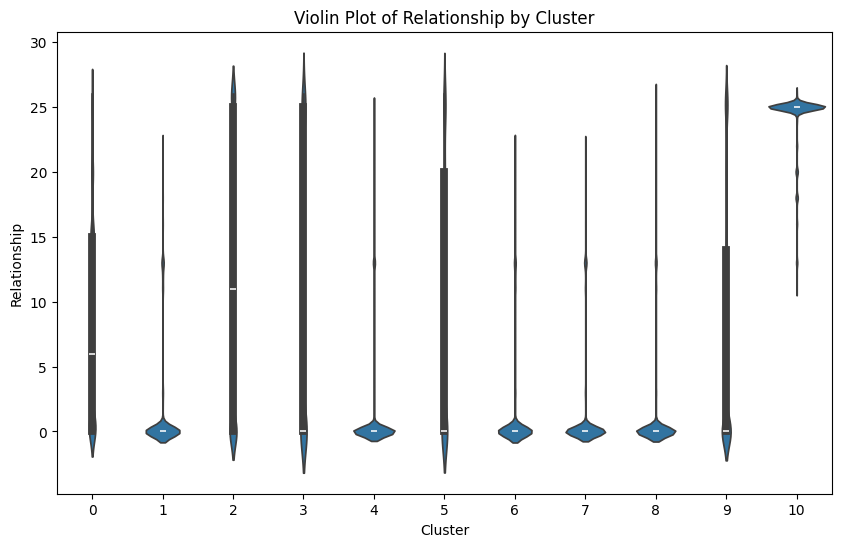

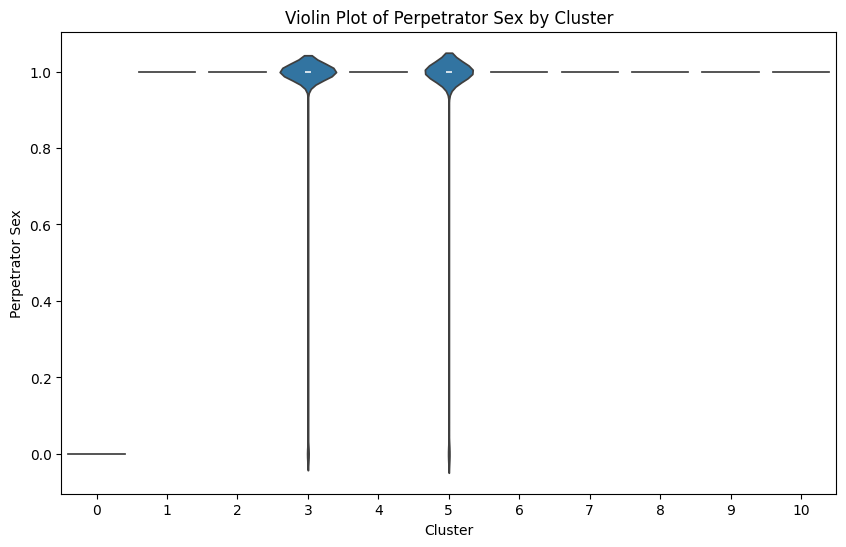

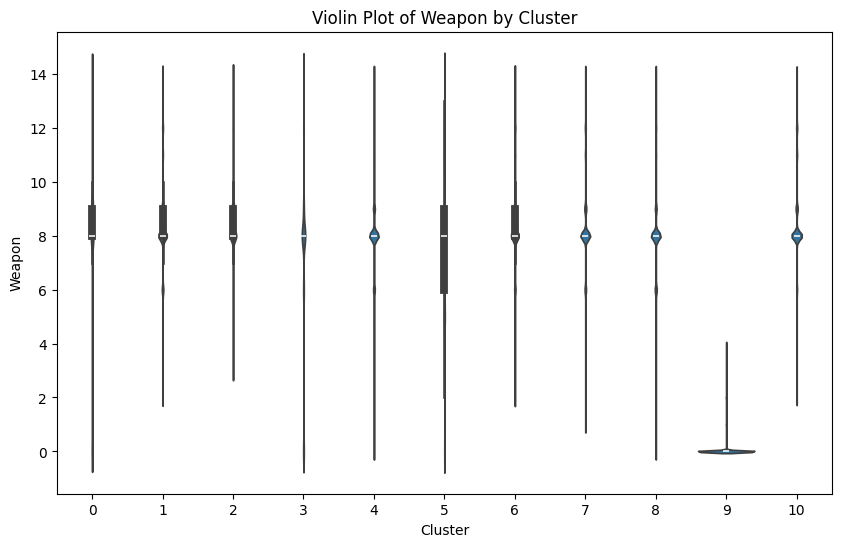

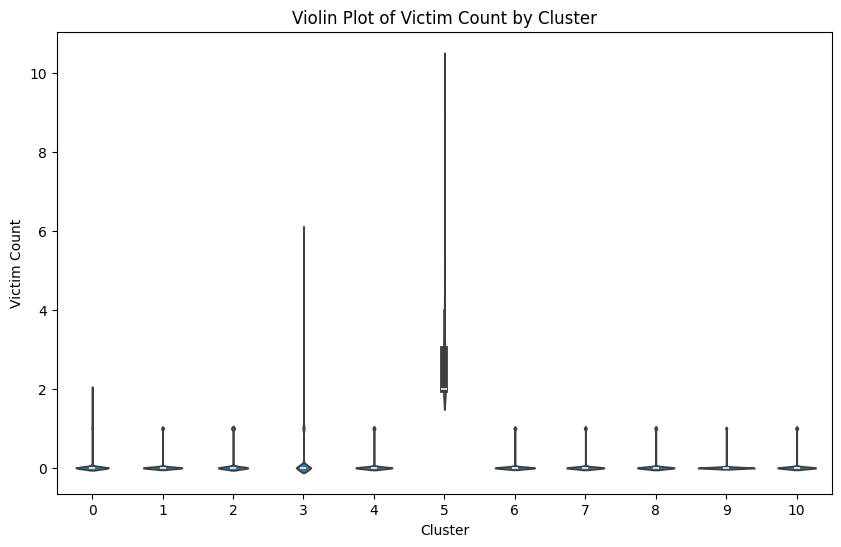

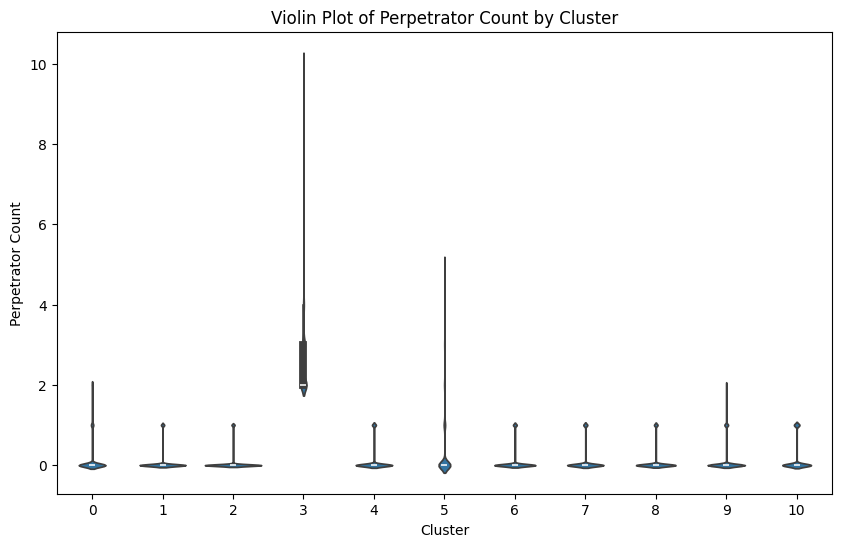

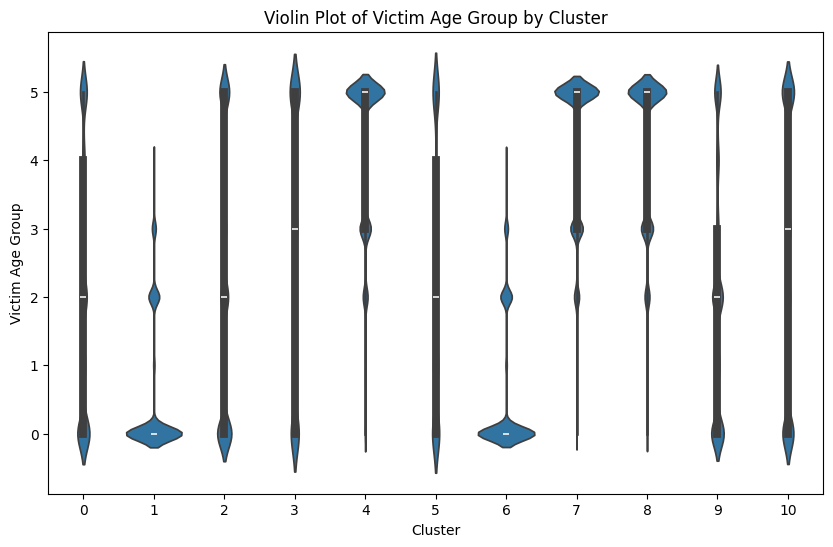

In [124]:
homicide_data["Cluster"] = kmeans.labels_

features = ['City', 'State', 'Year', 'Month', 'Victim Sex','Relationship','Perpetrator Sex','Weapon', 'Victim Count', 'Perpetrator Count', 'Victim Age Group']

for feature in features:
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Cluster', y=feature, data=homicide_data)
    plt.title(f'Violin Plot of {feature} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.show()

In [42]:
# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
homicide_data['PCA1'] = X_pca[:, 0]
homicide_data['PCA2'] = X_pca[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title('K-Means Crime Clusters')
plt.show()

ValueError: Could not interpret value `Cluster` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [41]:
# Count the number of cases per cluster
cluster_counts = homicide_data['Cluster'].value_counts().sort_index()

# Bar chart of cluster sizes
plt.figure(figsize=(12, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='tab10')
plt.xlabel('Cluster Number')
plt.ylabel('Number of Cases')
plt.title('Cluster Size Distribution')
plt.show()


KeyError: 'Cluster'

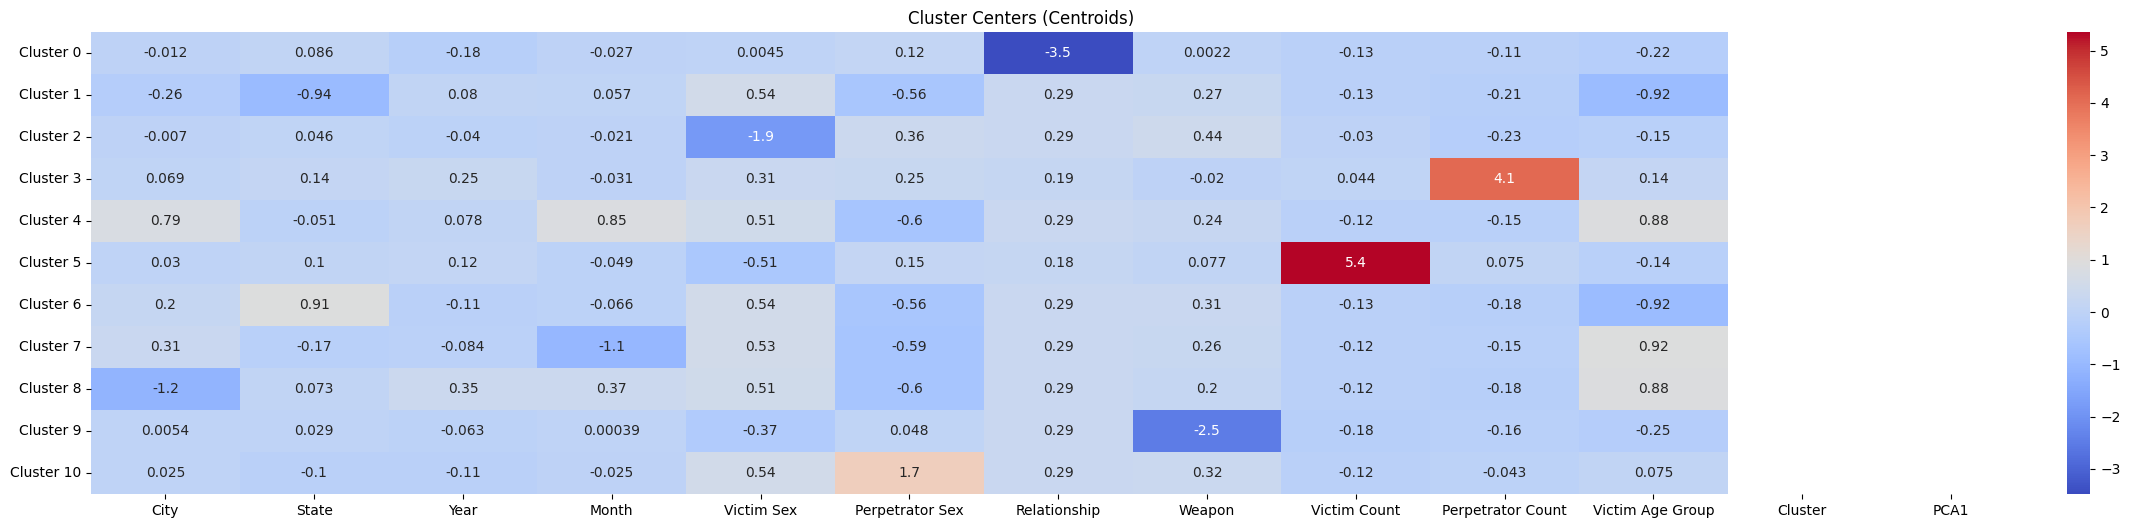

In [127]:
# You can also explore cluster centers (centroids)
centroids = kmeans.cluster_centers_

# Plot centroids to understand cluster centers
plt.figure(figsize=(30, 6))
sns.heatmap(centroids, annot=True, cmap='coolwarm', xticklabels=homicide_data.columns[:-1], yticklabels=[f'Cluster {i}' for i in range(kmeans.n_clusters)])
plt.title("Cluster Centers (Centroids)")
plt.show()

In [128]:
homicide_data.head()

,City,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Cluster,PCA1,PCA2
484984,87,20,1996,8,1,1,0,8,0,0,2,8,0.874705,-0.455741
608445,539,30,2013,9,1,1,25,8,0,0,5,10,0.281601,0.858424
417612,1695,22,1997,11,1,1,0,6,0,0,5,4,1.279523,0.154611
372692,425,9,1995,12,1,1,20,0,0,0,1,9,-0.661839,-0.056278
402028,946,4,2002,11,1,1,25,8,0,0,3,10,-0.045028,0.002723


,City,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,PCA1,PCA2
Cluster,,,,,,,,,,,,,
0,223333.700218,231.585526,101.203155,11.622270,0.173065,0.000000,69.071857,10.635093,0.066407,0.147349,3.754970,0.764723,0.662399
1,165897.341405,37.847037,99.585751,10.762442,0.000000,0.000000,14.856581,2.033700,0.052004,0.060864,0.868524,0.118456,0.397274
2,217606.795604,231.286328,97.672772,11.690754,0.000000,0.000000,118.658875,3.243795,0.095576,0.049585,4.123371,0.565041,0.455883
3,212799.019289,242.705526,94.558135,11.554236,0.086649,0.025118,140.542023,8.319185,0.209263,1.003459,4.318967,0.945565,1.692802
4,73299.244100,202.036912,94.388030,3.593539,0.009840,0.000000,10.756887,1.860237,0.057103,0.086758,1.392356,0.139194,0.445023
5,218454.811874,227.862908,102.915136,11.960837,0.245929,0.026362,108.927001,6.823287,2.960270,0.385514,3.596646,2.176288,3.281224
6,197127.933085,56.895110,95.993618,10.671700,0.000000,0.000000,15.629652,2.241396,0.051513,0.075616,0.852784,0.103442,0.431406
7,140352.065246,202.391759,91.787658,2.662469,0.005002,0.000000,11.795225,1.833329,0.054396,0.088378,1.123377,0.130651,0.441912
8,47544.961447,188.055924,92.025806,8.108073,0.011033,0.000000,12.025029,1.797947,0.055252,0.074564,1.341763,0.141397,0.420620


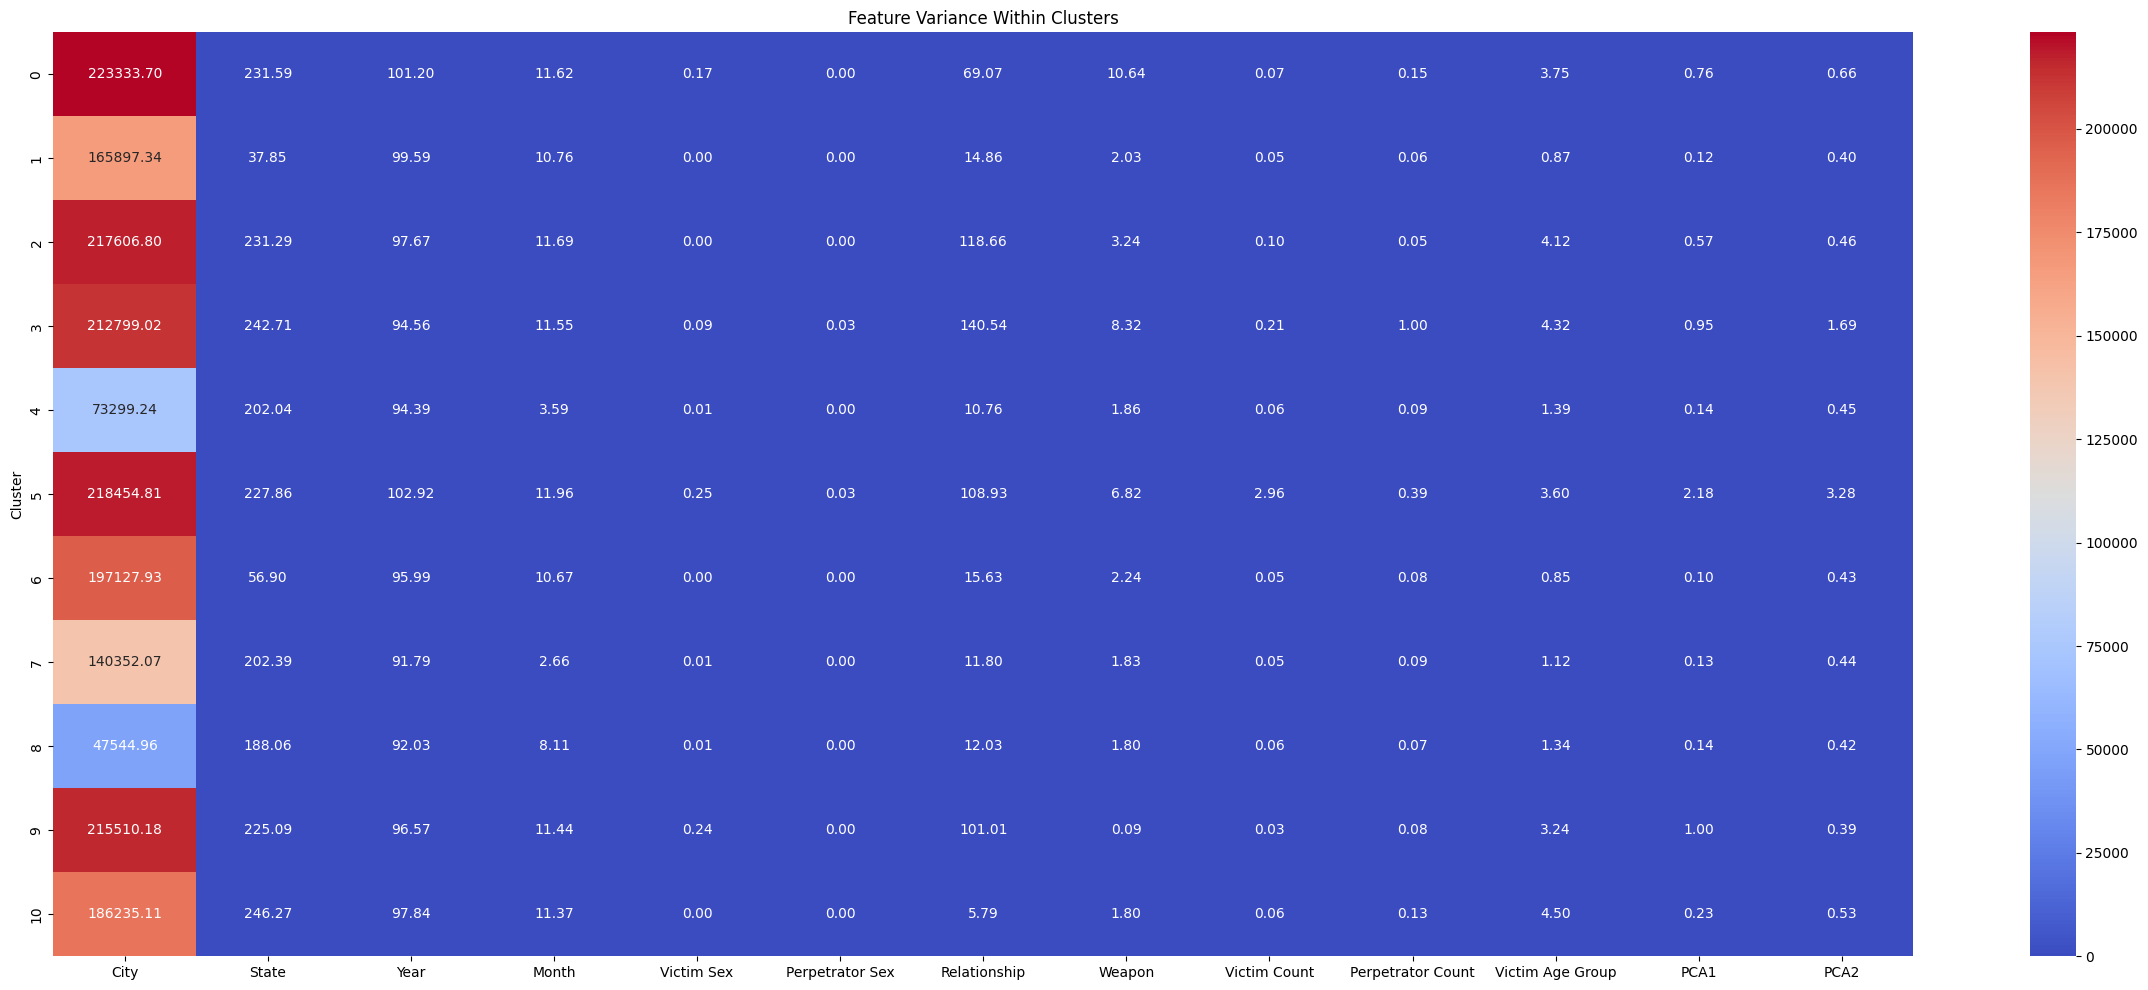

In [129]:
# Calculate feature variance within clusters
feature_variance = homicide_data.groupby('Cluster').var()
display(feature_variance)

# Visualize feature variance across clusters
plt.figure(figsize=(30, 12))
sns.heatmap(feature_variance, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Feature Variance Within Clusters")
plt.show()


In [134]:
# Step 2: Calculate the centroids of the clusters
centroids = kmeans.cluster_centers_

# Step 3: Compute the Euclidean distances between the centroids
distances = np.linalg.norm(centroids[:, np.newaxis] - centroids, axis=2)

# Step 4: Print the distances between each pair of centroids
print("Euclidean distances between each pair of centroids:")
for i in range(len(centroids)):
    for j in range(i + 1, len(centroids)):
        print(f"Distance between Cluster {i} and Cluster {j}: {distances[i, j]:.4f}")

Euclidean distances between each pair of centroids:
Distance between Cluster 0 and Cluster 1: 4.0915
Distance between Cluster 0 and Cluster 2: 4.2428
Distance between Cluster 0 and Cluster 3: 5.6275
Distance between Cluster 0 and Cluster 4: 4.2168
Distance between Cluster 0 and Cluster 5: 6.6296
Distance between Cluster 0 and Cluster 6: 4.0373
Distance between Cluster 0 and Cluster 7: 4.1976
Distance between Cluster 0 and Cluster 8: 4.2426
Distance between Cluster 0 and Cluster 9: 4.5458
Distance between Cluster 0 and Cluster 10: 4.1479
Distance between Cluster 1 and Cluster 2: 2.8777
Distance between Cluster 1 and Cluster 3: 4.6647
Distance between Cluster 1 and Cluster 4: 2.4009
Distance between Cluster 1 and Cluster 5: 5.7888
Distance between Cluster 1 and Cluster 6: 1.9137
Distance between Cluster 1 and Cluster 7: 2.3615
Distance between Cluster 1 and Cluster 8: 2.2898
Distance between Cluster 1 and Cluster 9: 3.2220
Distance between Cluster 1 and Cluster 10: 2.6268
Distance betwee

In [132]:
low_variance_threshold = 0.1# You can adjust this value

for cluster in feature_variance.index:
    cluster_variance = feature_variance.loc[cluster]
    low_variance_features = cluster_variance[cluster_variance < low_variance_threshold]

    print(f"Cluster {cluster} - Low variance features:")
    print(low_variance_features)
    print("---")


Cluster 0 - Low variance features:
Perpetrator Sex    0.000000
Victim Count       0.066407
Name: 0, dtype: float64
---
Cluster 1 - Low variance features:
Victim Sex           0.000000
Perpetrator Sex      0.000000
Victim Count         0.052004
Perpetrator Count    0.060864
Name: 1, dtype: float64
---
Cluster 2 - Low variance features:
Victim Sex           0.000000
Perpetrator Sex      0.000000
Victim Count         0.095576
Perpetrator Count    0.049585
Name: 2, dtype: float64
---
Cluster 3 - Low variance features:
Victim Sex         0.086649
Perpetrator Sex    0.025118
Name: 3, dtype: float64
---
Cluster 4 - Low variance features:
Victim Sex           0.009840
Perpetrator Sex      0.000000
Victim Count         0.057103
Perpetrator Count    0.086758
Name: 4, dtype: float64
---
Cluster 5 - Low variance features:
Perpetrator Sex    0.026362
Name: 5, dtype: float64
---
Cluster 6 - Low variance features:
Victim Sex           0.000000
Perpetrator Sex      0.000000
Victim Count         0.0515

Merged Cluster Counts:
 Merged_Cluster
1.0    494607
9.0     60495
0.0     47610
3.0     23156
5.0     12586
Name: count, dtype: int64


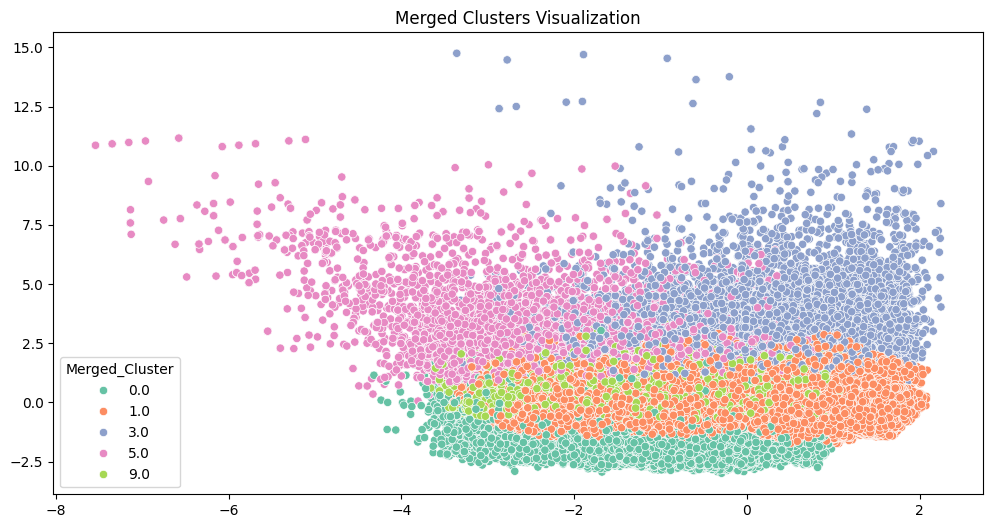

In [137]:
threshold = 3.0

# Step 5: Identify clusters to merge
# Create a list to keep track of merged clusters
merged_clusters = {}

# Loop through the distance matrix and check if the distance is below the threshold
for i in range(len(centroids)):
    for j in range(i + 1, len(centroids)):
        if distances[i, j] < threshold:
            # If the clusters are close enough, merge them by assigning the same new cluster label
            if i not in merged_clusters:
                merged_clusters[i] = i  # Assign the cluster i to its own set initially
            if j not in merged_clusters:
                merged_clusters[j] = i  # Merge cluster j into cluster i

# Step 6: Adjust the cluster labels based on the merged clusters
# Update the cluster labels based on the merged clusters
def merge_clusters(row):
    current_cluster = row['Cluster']
    # If the cluster is part of the merged clusters, assign the new merged label
    if current_cluster in merged_clusters:
        return merged_clusters[current_cluster]
    else:
        return current_cluster

# Apply the merge logic to the DataFrame
homicide_data['Merged_Cluster'] = homicide_data.apply(merge_clusters, axis=1)

# Step 7: Check the new merged clusters
merged_cluster_counts = homicide_data['Merged_Cluster'].value_counts()
print("Merged Cluster Counts:\n", merged_cluster_counts)

# You can also visualize the merged clusters, for example, using PCA to reduce dimensions and plot:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Perform PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X_scaled)  # Replace with relevant features

# Create a scatter plot of the reduced data with the new merged cluster labels
plt.figure(figsize=(12, 6))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=homicide_data['Merged_Cluster'], palette='Set2')
plt.title('Merged Clusters Visualization')
plt.show()

In [138]:
centroids = kmeans.cluster_centers_

# Step 3: Compute the Euclidean distances between the centroids
distances = np.linalg.norm(centroids[:, np.newaxis] - centroids, axis=2)

# Step 4: Define a function to merge clusters based on distance
def merge_clusters(centroids, distances, threshold):
    merged_clusters = np.arange(len(centroids))  # Initial cluster labels
    merged_centroids = centroids.copy()  # Make a copy to modify centroids

    # While there are more than 2 clusters, merge the closest ones
    while len(np.unique(merged_clusters)) > 2:
        # Find the pair of clusters with the smallest distance
        i, j = np.unravel_index(np.argmin(distances), distances.shape)

        if i == j:  # Skip diagonal (distance to itself)
            distances[i, j] = np.inf
            continue

        if distances[i, j] < threshold:  # Merge clusters if their distance is below threshold
            # Merge clusters i and j by assigning them the same label
            merged_clusters[merged_clusters == j] = i
            merged_centroids[i] = np.mean(centroids[merged_clusters == i], axis=0)  # Recalculate merged centroid

            # Update the distances matrix after merging
            for k in range(len(centroids)):
                if k != i:
                    distances[i, k] = distances[k, i] = np.linalg.norm(merged_centroids[i] - centroids[k])
            distances[j, :] = distances[:, j] = np.inf  # Remove the merged cluster

        else:
            break  # Stop merging if no clusters are close enough

    return merged_clusters, merged_centroids

# Step 5: Apply the merge function to get 2 final clusters
threshold = 3.0  # Distance threshold for merging clusters
final_clusters, final_centroids = merge_clusters(centroids, distances, threshold)

# Step 6: Assign the new cluster labels to the data
homicide_data['Merged_Cluster'] = final_clusters

# Step 7: Check the final cluster distribution
final_cluster_counts = homicide_data['Merged_Cluster'].value_counts()
print("Final Cluster Counts (Serial vs Non-Serial):\n", final_cluster_counts)

# Step 8: Visualize the final clusters
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Perform PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X_scaled)  # Replace with relevant features

# Create a scatter plot of the reduced data with the final merged clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=homicide_data['Merged_Cluster'], palette='Set2')
plt.title('Merged Clusters Visualization (Serial vs Non-Serial)')
plt.show()

KeyboardInterrupt: 

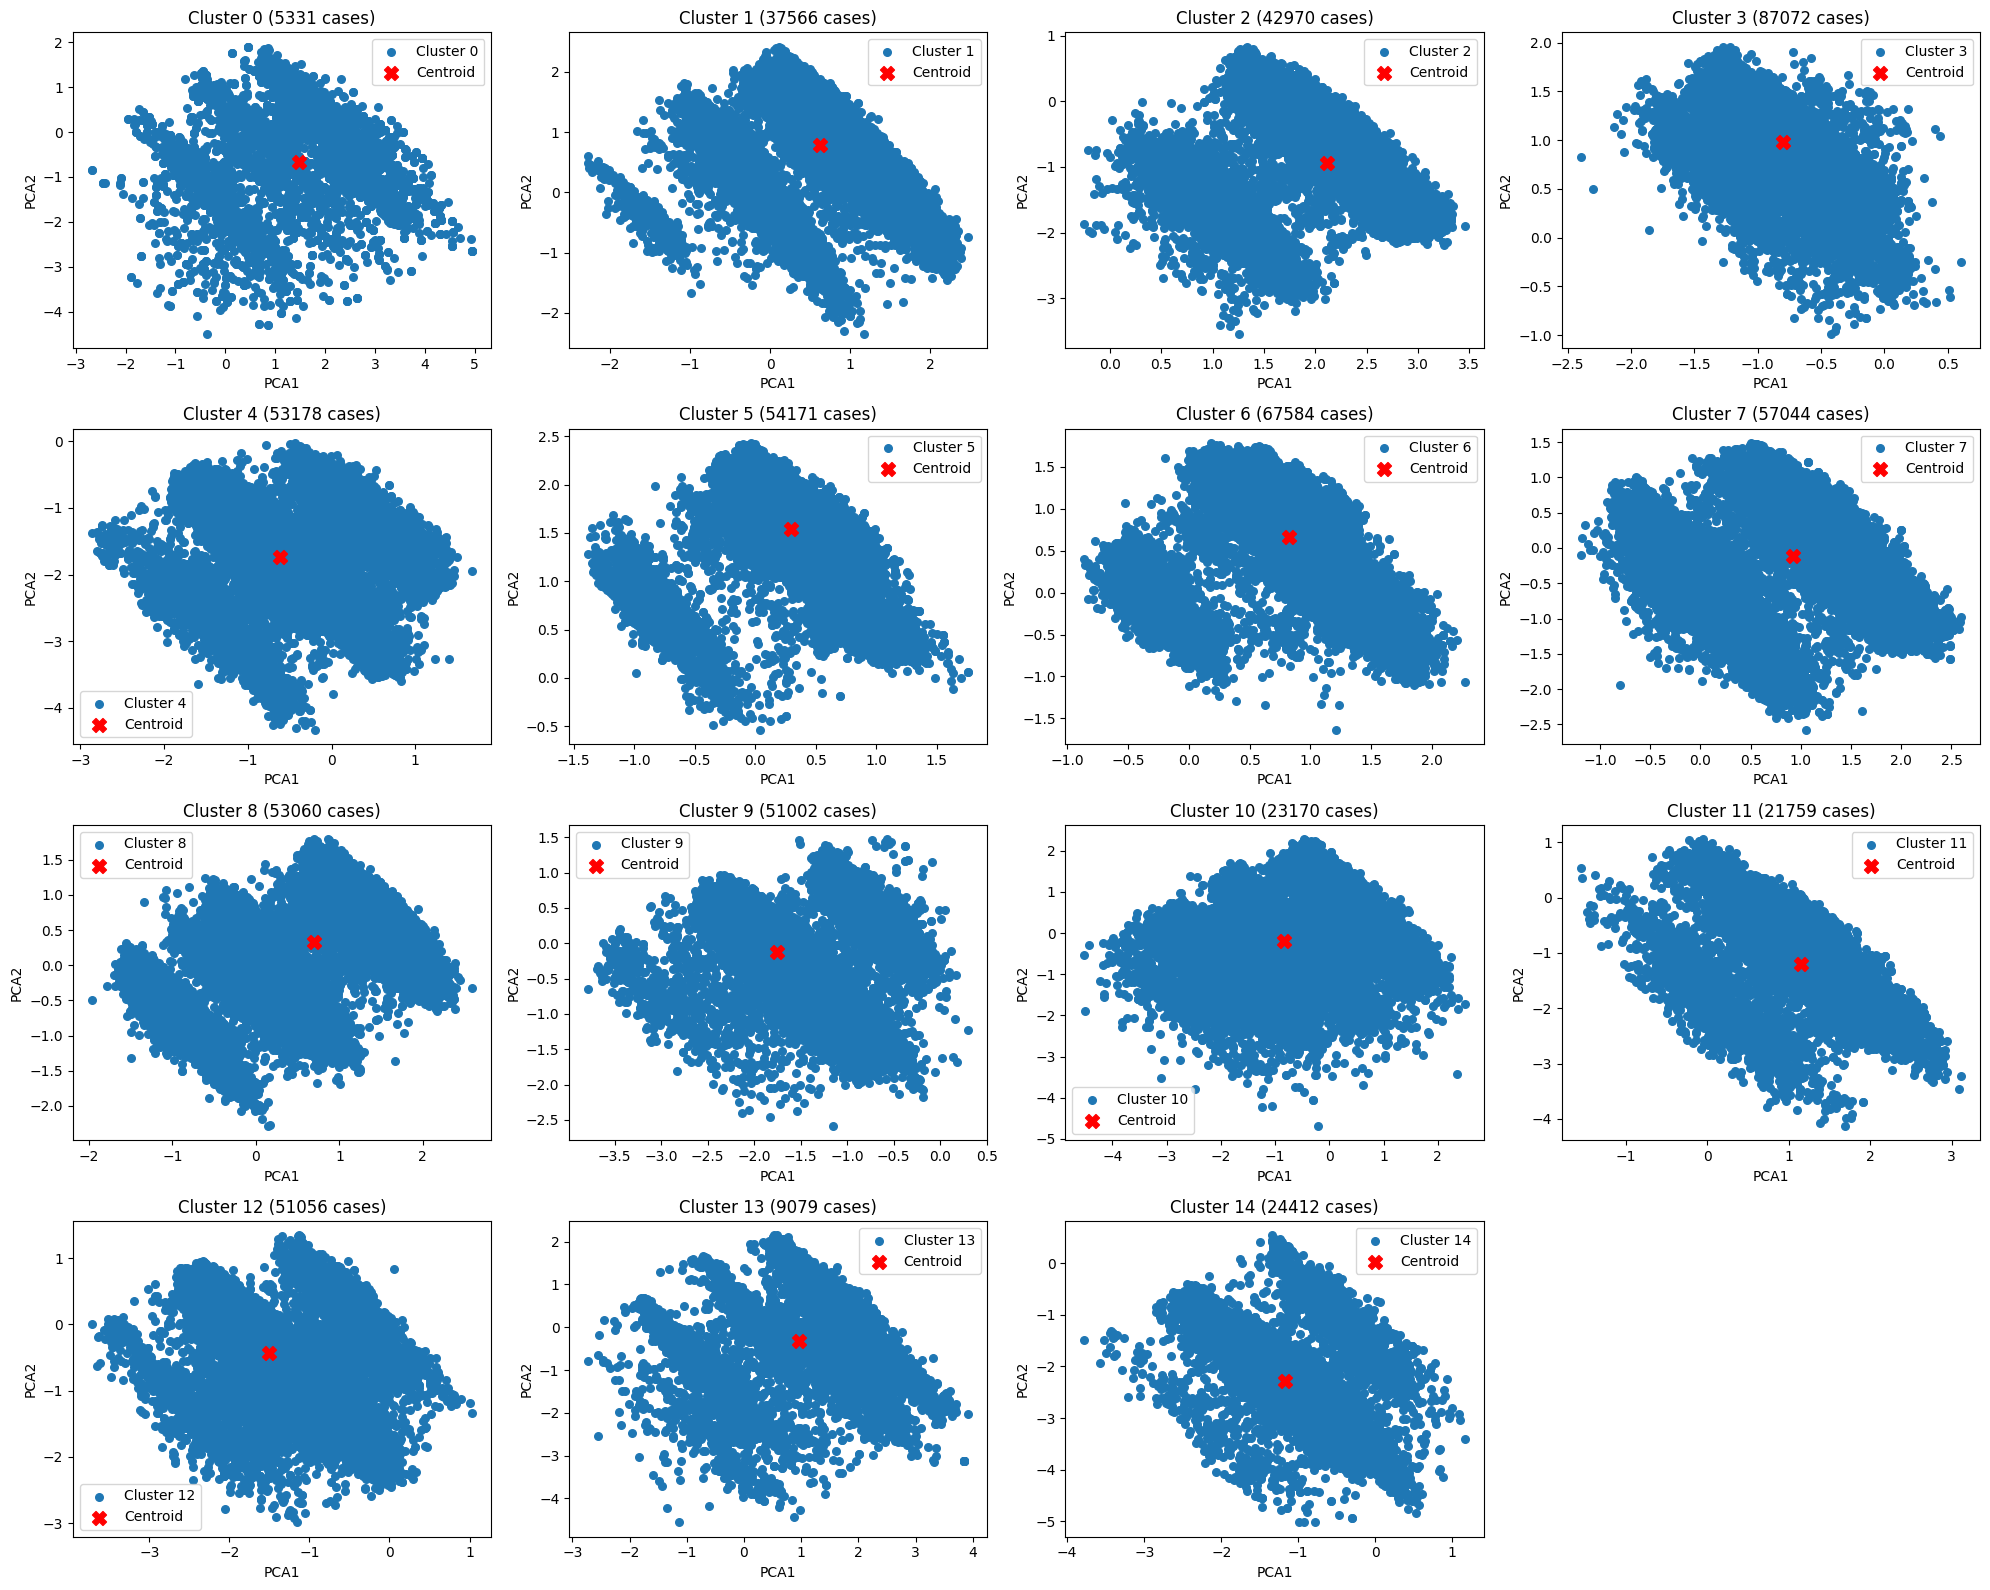

In [24]:
unique_clusters = homicide_data['Cluster'].unique()
num_clusters = len(unique_clusters)

# Create subplots (4x4 grid to fit 14 clusters, leaving 2 empty)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

for i, cluster in enumerate(sorted(unique_clusters)):
    ax = axes[i]
    cluster_data = homicide_data[homicide_data['Cluster'] == cluster]

    # Scatter plot of the cluster points
    ax.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster}', s=30)

    # Calculate and plot the centroid (mean of PCA1 and PCA2)
    centroid_x = cluster_data['PCA1'].mean()
    centroid_y = cluster_data['PCA2'].mean()
    ax.scatter(centroid_x, centroid_y, color='red', marker='X', s=100, label='Centroid')

    count = len(cluster_data)
    ax.set_title(f'Cluster {cluster} ({count} cases)')
    ax.set_xlabel('PCA1')
    ax.set_ylabel('PCA2')
    ax.legend()

# Hide unused subplots (since 16 subplots but only 14 clusters)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [74]:
centroids = kmeans.cluster_centers_

# Apply PCA to reduce centroids' coordinates to 2D
pca = PCA(n_components=2)
centroids_2d = pca.fit_transform(centroids)  # Transform centroids into 2D space

# Print the 2D coordinates of the centroids
for i, centroid in enumerate(centroids_2d):
    print(f"Centroid of Cluster {i}: {centroid}")

Centroid of Cluster 0: [ 7.10685077 -0.08394062]
Centroid of Cluster 1: [-0.82153563 -0.30227965]
Centroid of Cluster 2: [-0.64170292  3.63129558]
Centroid of Cluster 3: [-0.84969311 -0.06928447]
Centroid of Cluster 4: [-0.77269309 -0.30666944]
Centroid of Cluster 5: [-0.95280536 -1.63251933]
Centroid of Cluster 6: [-0.8619974  -0.02806607]
Centroid of Cluster 7: [-0.84160236 -0.42565472]
Centroid of Cluster 8: [-0.45145644 -0.58529611]
Centroid of Cluster 9: [-0.91336446 -0.19758517]


Advanced

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


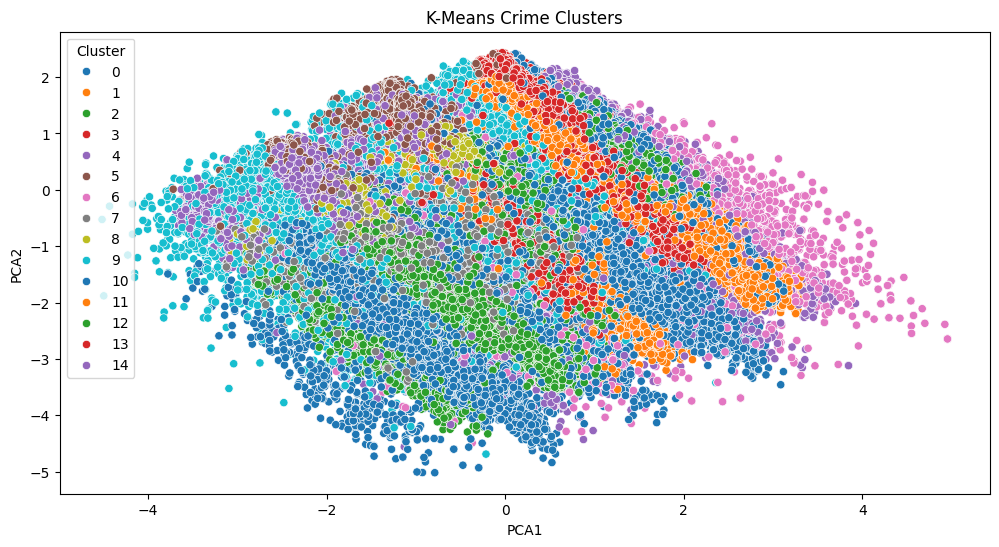

In [23]:
# K-Means Clustering
kmeans = KMeans(n_clusters=15, random_state=42)
homicide_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
homicide_data['PCA1'] = X_pca[:, 0]
homicide_data['PCA2'] = X_pca[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title('K-Means Crime Clusters')
plt.show()

In [24]:
homicide_data['Cluster'].value_counts()

,count
Cluster,
13,64649
1,61212
10,58651
4,55459
8,52187
3,49601
5,48000
2,46982
12,46345


In [25]:
top_clusters = homicide_data['Cluster'].value_counts().head(2).index.tolist()
homicide_data['Serial_Crime'] = homicide_data['Cluster'].apply(lambda x: 1 if x in top_clusters else 0)

In [26]:
# Value count for serial crime
homicide_data['Serial_Crime'].value_counts()

,count
Serial_Crime,
0,512593
1,125861


In [28]:
# Use features and target
y = homicide_data['Serial_Crime']

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
# Build KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on training data
y_train_pred = knn.predict(X_train)

# Predict on test data
y_test_pred = knn.predict(X_test)

# Accuracy report
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nTesting Accuracy:", accuracy_score(y_test, y_test_pred))

# Detailed classification report
print("\nClassification Report (Test Data):\n")
print(classification_report(y_test, y_test_pred))


Training Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    358782
           1       1.00      1.00      1.00     88135

    accuracy                           1.00    446917
   macro avg       1.00      1.00      1.00    446917
weighted avg       1.00      1.00      1.00    446917


Testing Accuracy: 0.997253794306061
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    153811
           1       0.99      0.99      0.99     37726

    accuracy                           1.00    191537
   macro avg       1.00      0.99      1.00    191537
weighted avg       1.00      1.00      1.00    191537



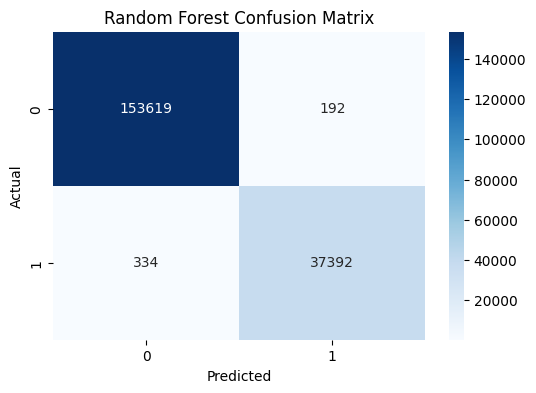

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Accuracy Reports
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

print("\nTesting Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=2, min_samples=5)
homicide_data['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Plot DBSCAN Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='tab10')
plt.title('DBSCAN Crime Clusters')
plt.show()

NameError: name 'DBSCAN' is not defined

In [ ]:
# Check cluster composition
for cluster in homicide_data['KMeans_Cluster'].unique():
    print(f"\nCluster {cluster} sample crimes:")
    print(homicide_data[homicide_data['KMeans_Cluster'] == cluster][features].head())